# Import Library

In [ ]:
import pandas as pd

# Load dataset

In [ ]:
df  = pd.read_csv("/content/events.csv")
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1.515916e+18,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1.515916e+18,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1.515916e+18,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1.515916e+18,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1.515916e+18,aa4mmk0kwQ
...,...,...,...,...,...,...,...,...,...
721275,2021-02-01 13:09:52 UTC,cart,1821815,2144415922427789416,computers.components.videocards,gigabyte,446.51,1.515916e+18,pYn40Zxfxu
721276,2021-02-01 13:09:54 UTC,view,408472,2144415925011480748,stationery.cartrige,NaN,14.08,1.515916e+18,XJjdH5NCcW
721277,2021-02-01 13:10:02 UTC,view,1255182,2144415942568837766,NaN,ion,205.89,1.515916e+18,rMSjLgYQu0
721278,2021-02-01 13:10:03 UTC,view,1667761,2144415927049912542,electronics.video.tv,jvc,161.30,1.515916e+18,6UAJvUrle5


In [ ]:
# Summary dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721280 entries, 0 to 721279
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     721280 non-null  object 
 1   event_type     721280 non-null  object 
 2   product_id     721280 non-null  int64  
 3   category_id    721280 non-null  int64  
 4   category_code  524915 non-null  object 
 5   brand          546701 non-null  object 
 6   price          721279 non-null  float64
 7   user_id        721279 non-null  float64
 8   user_session   721121 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 49.5+ MB


# Data Type change

In [ ]:
# change object -> time
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)

# cange int -> object
cols = ['product_id', 'category_id', 'user_id']
df[cols] = df[cols].astype(str)

# change object to category
category_cols = ['event_type', 'category_code', 'brand']
df[category_cols] = df[category_cols].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721280 entries, 0 to 721279
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     721280 non-null  datetime64[ns, UTC]
 1   event_type     721280 non-null  category           
 2   product_id     721280 non-null  object             
 3   category_id    721280 non-null  object             
 4   category_code  524915 non-null  category           
 5   brand          546701 non-null  category           
 6   price          721279 non-null  float64            
 7   user_id        721280 non-null  object             
 8   user_session   721121 non-null  object             
dtypes: category(3), datetime64[ns, UTC](1), float64(1), object(4)
memory usage: 35.8+ MB


In [ ]:
df.describe(include='all')

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
count,721280,721280,721280,721280,524915,546701,721279.000000,721280,721121
unique,NaN,3,50514,710,108,982,NaN,163997,404198
top,NaN,view,1821813,2144415922427789416,computers.components.videocards,asus,NaN,1.5159156255277632e+18,9HqvxzKlPb
freq,NaN,648672,9342,79183,79182,20913,NaN,427,424
mean,2020-11-30 07:14:54.452004608+00:00,NaN,NaN,NaN,NaN,NaN,139.626977,NaN,NaN
min,2020-09-24 11:57:06+00:00,NaN,NaN,NaN,NaN,NaN,0.220000,NaN,NaN
25%,2020-10-30 09:51:33+00:00,NaN,NaN,NaN,NaN,NaN,25.510000,NaN,NaN
50%,2020-11-27 11:27:52+00:00,NaN,NaN,NaN,NaN,NaN,63.940000,NaN,NaN
75%,2021-01-03 13:39:51.249999872+00:00,NaN,NaN,NaN,NaN,NaN,175.830000,NaN,NaN
max,2021-02-01 13:10:05+00:00,NaN,NaN,NaN,NaN,NaN,64771.060000,NaN,NaN


# Check duplicated

In [ ]:
# Sum of duplicated
df.duplicated().sum()

np.int64(563)

In [ ]:
# Detail of duplicated
df[df.duplicated(keep=False)]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
511,2020-09-24 13:51:07+00:00,view,387956,2144415922427789416,computers.components.videocards,asus,104.21,1.51591562551943e+18,PZu2caZ5EN
512,2020-09-24 13:51:07+00:00,view,387956,2144415922427789416,computers.components.videocards,asus,104.21,1.51591562551943e+18,PZu2caZ5EN
974,2020-09-24 15:48:55+00:00,view,874667,2144415922738167921,computers.components.cdrw,asus,23.48,1.515915625519457e+18,8wvs0vbHtv
975,2020-09-24 15:48:55+00:00,view,874667,2144415922738167921,computers.components.cdrw,asus,23.48,1.515915625519457e+18,8wvs0vbHtv
4827,2020-09-25 13:15:09+00:00,view,453469,2144415924222951574,auto.accessories.parktronic,NaN,69.84,1.5159156255197258e+18,9ofICyh8Eo
...,...,...,...,...,...,...,...,...,...
718787,2021-02-01 06:05:35+00:00,view,4154620,2144415922427789416,computers.components.videocards,msi,656.63,1.5159156255970747e+18,guJPKKliWM
719125,2021-02-01 07:11:25+00:00,view,68062,2144415925011480748,stationery.cartrige,cactus,27.75,1.5159156255993132e+18,Znrg0dyTPK
719126,2021-02-01 07:11:25+00:00,view,68062,2144415925011480748,stationery.cartrige,cactus,27.75,1.5159156255993132e+18,Znrg0dyTPK
720920,2021-02-01 12:11:50+00:00,view,898777,2144415945681011417,NaN,NaN,77.87,1.5159156255994102e+18,8wznMjqf9V


In [ ]:
# Drop duplicated
df = df.drop_duplicates()

In [ ]:
# Check duplicated
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check detail duplicated of user session
df[df['user_session'].duplicated(keep=False)].sort_values(by='user_session')

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
221736,2020-11-06 01:25:30+00:00,view,3605162,2144415924684325027,electronics.audio.headphone,NaN,18.86,1.5159156255361413e+18,001P7lK0Pt
221737,2020-11-06 01:25:43+00:00,view,3585175,2144415924684325027,electronics.audio.headphone,samsung,148.84,1.5159156255361413e+18,001P7lK0Pt
200822,2020-11-02 18:12:33+00:00,view,1400332,2144415939330834990,computers.peripherals.printer,NaN,9.84,1.5159156255338578e+18,003pEktS1X
200814,2020-11-02 18:11:24+00:00,view,80548,2144415925011480748,stationery.cartrige,cactus,16.05,1.5159156255338578e+18,003pEktS1X
222045,2020-11-06 04:40:04+00:00,view,1586099,2144415924751433893,computers.notebook,mobilepc,35.08,1.5159156255361695e+18,005wDfXQrv
...,...,...,...,...,...,...,...,...,...
708977,2021-01-30 12:30:31+00:00,view,4102491,2144415950470906727,construction.tools.welding,NaN,22.19,1.515915625598707e+18,NaN
709335,2021-01-30 13:31:54+00:00,cart,4102491,2144415950470906727,construction.tools.welding,NaN,22.19,1.515915625598707e+18,NaN
709352,2021-01-30 13:35:15+00:00,view,4102491,2144415950470906727,construction.tools.welding,NaN,22.19,1.5159156255987249e+18,NaN
709354,2021-01-30 13:35:54+00:00,view,4102491,2144415950470906727,construction.tools.welding,NaN,22.19,1.515915625598707e+18,NaN


The presence of duplicate user_session values is normal in this dataset, since a single session can include multiple product interactions

In [ ]:
# check duplicated of user_id
df[df['user_id'].duplicated(keep=False)].sort_values(by='user_id')

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
306439,2020-11-18 10:51:42+00:00,view,254763,2144415924424278172,electronics.audio.acoustic,creative,74.24,1.5159156253532306e+18,AXbHvG5BRP
430564,2020-12-12 10:33:09+00:00,view,1848366,2144415923107266682,computers.peripherals.printer,canon,339.79,1.5159156253532306e+18,YSbSzDlwcX
306508,2020-11-18 10:59:17+00:00,view,254763,2144415924424278172,electronics.audio.acoustic,creative,74.24,1.5159156253532306e+18,5qXvZIBV2W
242211,2020-11-09 08:52:51+00:00,view,124883,2144415924424278172,electronics.audio.acoustic,logitech,23.90,1.5159156253532306e+18,dn9FkZ11dA
242297,2020-11-09 09:04:34+00:00,view,760044,2144415924424278172,electronics.audio.acoustic,dell,48.73,1.5159156253532306e+18,dn9FkZ11dA
...,...,...,...,...,...,...,...,...,...
721107,2021-02-01 12:42:16+00:00,cart,1021721,2144415922528452715,electronics.telephone,NaN,28.73,1.51591562559942e+18,jD6tgS21kJ
721110,2021-02-01 12:43:43+00:00,purchase,1021721,2144415922528452715,electronics.telephone,NaN,28.73,1.51591562559942e+18,jD6tgS21kJ
721119,2021-02-01 12:46:28+00:00,view,1821578,2144415922528452715,electronics.telephone,sirius,18.57,1.51591562559942e+18,jD6tgS21kJ
721118,2021-02-01 12:46:25+00:00,view,405151,2144415922528452715,electronics.telephone,NaN,17.62,1.51591562559942e+18,jD6tgS21kJ


Duplicate user_id values indicate that a single user may browse multiple products, either within the same category at different price points or across different categories

# Check missing value

In [ ]:
# sum of missing value by column
missing_df = (df.isna().sum().reset_index(name="missing_count").rename(columns={'index': 'column'}))

missing_df['missing_percentage'] = (missing_df['missing_count']/len(df) * 100).round(2)
missing_df

,column,missing_count,missing_percentage
0,event_time,0,0.00
1,event_type,0,0.00
2,product_id,0,0.00
3,category_id,0,0.00
4,category_code,196215,27.22
5,brand,174471,24.21
6,price,1,0.00
7,user_id,0,0.00
8,user_session,156,0.02


In [ ]:
# Fill missing value
unknown_cols = ['category_code', 'brand', 'user_session']
df[unknown_cols] = df[unknown_cols].astype('string').fillna('unknown')

/tmp/ipython-input-4135236868.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[unknown_cols] = df[unknown_cols].astype('string').fillna('unknown')


In [ ]:
# Check missing value
df.isna().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,0
brand,0
price,1
user_id,0
user_session,0


In [ ]:
# Check in detail of missing value
for i in df.columns:
    print(f'Column: {i}')
    print(df[i].unique())
    print('-' * 50)

Column: event_time
<DatetimeArray>
['2020-09-24 11:57:06+00:00', '2020-09-24 11:57:26+00:00',
 '2020-09-24 11:57:27+00:00', '2020-09-24 11:57:33+00:00',
 '2020-09-24 11:57:36+00:00', '2020-09-24 11:57:59+00:00',
 '2020-09-24 11:58:23+00:00', '2020-09-24 11:58:24+00:00',
 '2020-09-24 11:58:25+00:00', '2020-09-24 11:58:31+00:00',
 ...
 '2021-02-01 13:09:33+00:00', '2021-02-01 13:09:34+00:00',
 '2021-02-01 13:09:36+00:00', '2021-02-01 13:09:41+00:00',
 '2021-02-01 13:09:47+00:00', '2021-02-01 13:09:52+00:00',
 '2021-02-01 13:09:54+00:00', '2021-02-01 13:10:02+00:00',
 '2021-02-01 13:10:03+00:00', '2021-02-01 13:10:05+00:00']
Length: 688939, dtype: datetime64[ns, UTC]
--------------------------------------------------
Column: event_type
['view', 'cart', 'purchase']
Categories (3, object): ['cart', 'purchase', 'view']
--------------------------------------------------
Column: product_id
['1996170' '139905' '215454' ... '367111' '1734587' '564236']
-------------------------------------------

In [ ]:
df[df['category_id'] == '2']

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session


In [ ]:
df[df['user_id'] == 'nan']

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
721279,2021-02-01 13:10:05+00:00,view,1821813,2144415922427789416,computers.c,unknown,NaN,nan,unknown


In [ ]:
df[df['price'].isna()]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
721279,2021-02-01 13:10:05+00:00,view,1821813,2144415922427789416,computers.c,unknown,NaN,nan,unknown


In [ ]:
# drop missing value of row price
df = df.dropna(subset=['price'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 720716 entries, 0 to 721278
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     720716 non-null  datetime64[ns, UTC]
 1   event_type     720716 non-null  category           
 2   product_id     720716 non-null  object             
 3   category_id    720716 non-null  object             
 4   category_code  720716 non-null  string             
 5   brand          720716 non-null  string             
 6   price          720716 non-null  float64            
 7   user_id        720716 non-null  object             
 8   user_session   720716 non-null  string             
dtypes: category(1), datetime64[ns, UTC](1), float64(1), object(3), string(3)
memory usage: 50.2+ MB


# Data manipulation

In [ ]:
# Time
df['date']  = df['event_time'].dt.date
df['year']  = df['event_time'].dt.year
df['month'] = df['event_time'].dt.month
df['day']   = df['event_time'].dt.day
df['hour']  = df['event_time'].dt.hour
df['day_name'] = df['event_time'].dt.day_name()

In [ ]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,year,month,day,hour,day_name
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,unknown,31.90,1.5159156255193882e+18,LJuJVLEjPT,2020-09-24,2020,9,24,11,Thursday
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1.5159156255193805e+18,tdicluNnRY,2020-09-24,2020,9,24,11,Thursday
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,unknown,unknown,9.81,1.5159156255132385e+18,4TMArHtXQy,2020-09-24,2020,9,24,11,Thursday
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1.5159156255190144e+18,aGFYrNgC08,2020-09-24,2020,9,24,11,Thursday
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,unknown,cameronsino,15.87,1.5159156255107433e+18,aa4mmk0kwQ,2020-09-24,2020,9,24,11,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721274,2021-02-01 13:09:47+00:00,view,3506612,2144415922872385653,electronics.tablet,arian,47.14,1.5159156255600735e+18,1tLdOwzjxO,2021-02-01,2021,2,1,13,Monday
721275,2021-02-01 13:09:52+00:00,cart,1821815,2144415922427789416,computers.components.videocards,gigabyte,446.51,1.515915625599429e+18,pYn40Zxfxu,2021-02-01,2021,2,1,13,Monday
721276,2021-02-01 13:09:54+00:00,view,408472,2144415925011480748,stationery.cartrige,unknown,14.08,1.5159156255987471e+18,XJjdH5NCcW,2021-02-01,2021,2,1,13,Monday
721277,2021-02-01 13:10:02+00:00,view,1255182,2144415942568837766,unknown,ion,205.89,1.51591562559807e+18,rMSjLgYQu0,2021-02-01,2021,2,1,13,Monday


In [ ]:
# make rfm tabel
reference_date = df['event_time'].max()

#recency
recency = (
    df[df['event_type'] == 'purchase']
    .groupby('user_id')['event_time']
    .max()
    .reset_index()
)

recency['recency'] = (reference_date - recency['event_time']).dt.days
recency = recency[['user_id', 'recency']]

# Frequency
frequency = (
    df[df['event_type'] == 'purchase']
    .groupby('user_id')
    .size()
    .reset_index(name='frequency')
)

# Monetary
monetary = (
    df[df['event_type'] == 'purchase']
    .groupby('user_id')['price']
    .sum()
    .reset_index(name='monetary')
)

rfm = recency.merge(frequency, on='user_id', how='left') \
             .merge(monetary, on='user_id', how='left')

rfm['frequency'] = rfm['frequency'].fillna(0)
rfm['monetary']  = rfm['monetary'].fillna(0)

In [ ]:
rfm.sort_values(by='frequency')

,user_id,recency,frequency,monetary
16422,1.5159156255994212e+18,0,1,1.57
16421,1.5159156255994097e+18,0,1,71.75
16420,1.5159156255994048e+18,0,1,9.35
16419,1.5159156255993987e+18,0,1,52.49
16400,1.5159156255993452e+18,0,1,382.94
...,...,...,...,...
6084,1.5159156255379994e+18,80,24,4091.56
14369,1.5159156255940052e+18,12,24,2132.57
15287,1.5159156255962222e+18,0,28,9886.04
15412,1.5159156255965348e+18,5,28,3396.36


In [ ]:
rfm['is_repeat'] = (rfm['frequency'] >= 2).astype(int)

# EDA

## New and returning customer

In [ ]:
df_purchase = df[df['event_type'] == 'purchase']

In [ ]:
df_purchase

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,year,month,day,hour,day_name
45,2020-09-24 12:04:10+00:00,purchase,1507291,2144415926806642904,computers.components.power_supply,supermicro,217.57,1.5159156255193905e+18,xn6SHCnZtk,2020-09-24,2020,9,24,12,Thursday
82,2020-09-24 12:15:06+00:00,purchase,822426,2144415922360680550,computers.peripherals.camera,logitech,123.35,1.5159156255135744e+18,2gngxS29Ts,2020-09-24,2020,9,24,12,Thursday
100,2020-09-24 12:19:01+00:00,purchase,4060928,2144415927049912542,electronics.video.tv,unknown,89.22,1.515915625518131e+18,3yFCkx2KKW,2020-09-24,2020,9,24,12,Thursday
132,2020-09-24 12:25:18+00:00,purchase,4060928,2144415927049912542,electronics.video.tv,unknown,89.22,1.515915625518131e+18,3yFCkx2KKW,2020-09-24,2020,9,24,12,Thursday
150,2020-09-24 12:29:49+00:00,purchase,1283197,2144415973413749245,computers.peripherals.nas,zyxel,123.79,1.515915625519356e+18,3jFpdbozOd,2020-09-24,2020,9,24,12,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721086,2021-02-01 12:38:51+00:00,purchase,3967707,2144415922427789416,computers.components.videocards,gigabyte,672.63,1.5159156255992172e+18,XArIldpbDi,2021-02-01,2021,2,1,12,Monday
721110,2021-02-01 12:43:43+00:00,purchase,1021721,2144415922528452715,electronics.telephone,unknown,28.73,1.51591562559942e+18,jD6tgS21kJ,2021-02-01,2021,2,1,12,Monday
721169,2021-02-01 12:52:49+00:00,purchase,3828952,2144415934608048556,computers.peripherals.printer,unknown,1.57,1.5159156255994212e+18,OYlVzrGegs,2021-02-01,2021,2,1,12,Monday
721197,2021-02-01 12:57:20+00:00,purchase,261142,2144415921253384266,unknown,unknown,38.83,1.5159156255994248e+18,If8P10VEuj,2021-02-01,2021,2,1,12,Monday


In [ ]:
# Total revenue
total_revenue = df_purchase['price'].sum()
total_revenue

np.float64(3763231.35)

In [ ]:
# Top product (menghasilkan uang terbanyak)
top_product = df_purchase.groupby('product_id')['price'].sum().sort_values(ascending=False).head()
top_product

,price
product_id,
1821813,143887.76
4099645,103954.65
3791351,71910.08
4079420,63830.42
4078916,58591.14


In [ ]:
# total revenue
total_revenue = df_purchase['price'].sum()

# revenue top 5 product
top5_revenueby_category = (
    df_purchase
    .groupby('category_code')['price']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .sum()
)

# kontribusi %
top5_percentage = (top5_revenueby_category / total_revenue) * 100

top5_percentage

np.float64(71.02454756070206)

In [ ]:
# Top product by order items (product yang paling banyak disukai)
top_product_items = (
    df_purchase.groupby('product_id', as_index=False)
      .size()
      .rename(columns={'size': 'total_items'})
      .sort_values('total_items', ascending=False)
      .head()
)

top_product_items

,product_id,total_items
3059,3829355,454
1752,1821813,362
3488,4099645,355
2930,3791351,352
2616,3642540,308


In [ ]:
# Top category code
top_category_code = (
    df_purchase.groupby('category_code', as_index=False)
      .size()
      .rename(columns={'size': 'total_items'})
      .sort_values('total_items', ascending=False)
      .head()
)

top_category_code

,category_code,total_items
88,unknown,6121
37,computers.components.videocards,4449
75,electronics.telephone,3431
85,stationery.cartrige,2371
48,computers.peripherals.printer,2182


In [ ]:
# Top brand
top_brand = (
    df_purchase.groupby('brand', as_index=False)
      .size()
      .rename(columns={'size': 'total_items'})
      .sort_values('total_items', ascending=False)
      .head()
)

top_brand

,brand,total_items
407,unknown,7728
138,gigabyte,1223
256,msi,1069
33,asus,903
61,canon,889


In [ ]:
 # Daily sales
 daily_sales = (
    df_purchase.groupby('date', as_index=False)['price']
      .sum()
      .sort_values('date')
)

daily_sales

,date,price
0,2020-09-24,9563.67
1,2020-09-25,13025.72
2,2020-09-26,11821.97
3,2020-09-27,7910.53
4,2020-09-28,15120.82
...,...,...
126,2021-01-28,48019.85
127,2021-01-29,41904.32
128,2021-01-30,45962.94
129,2021-01-31,51777.70


In [ ]:
# Sales tahunan
sales_tahunan = (
    df_purchase.groupby(['year'], as_index=False)
    .agg(total_revenue=('price', 'sum'))
    .sort_values(['year'])
)

sales_tahunan


,year,total_revenue
0,2020,2259897.65
1,2021,1503333.70


In [ ]:
sales_tahunan['revenue_growth_%'] = (
    sales_tahunan['total_revenue'].pct_change() * 100
).round(2)

sales_tahunan

,year,total_revenue,revenue_growth_%
0,2020,2259897.65,NaN
1,2021,1503333.70,-33.48


di tahun 2021 revenue naik 26.79%

In [ ]:
# Sales bulanan
sales_bulanan = (
    df_purchase.groupby(['year', 'month'], as_index=False)
    .agg(total_revenue=('price', 'sum'))
    .sort_values(['year', 'month'])
)

sales_bulanan


,year,month,total_revenue
0,2020,9,96353.01
1,2020,10,562590.39
2,2020,11,787886.24
3,2020,12,813068.01
4,2021,1,1488410.57
5,2021,2,14923.13


In [ ]:
# Best day
best_day = (
    df_purchase.groupby('day_name', as_index=False)
      .agg(total_orders=('event_time', 'count'))
      .sort_values('total_orders')
)

best_day

,day_name,total_orders
2,Saturday,3814
3,Sunday,4043
4,Thursday,4182
0,Friday,4213
5,Tuesday,4371
6,Wednesday,4444
1,Monday,4747


In [ ]:
# Best time
best_time = (
    df_purchase.groupby('hour', as_index=False)
      .agg(total_orders=('product_id', 'nunique'))
      .sort_values('hour')
)

best_time

,hour,total_orders
0,0,167
1,1,169
2,2,194
3,3,299
4,4,371
5,5,533
6,6,697
7,7,817
8,8,927
9,9,964


In [ ]:
# Revenue
customer_year = (
    df_purchase
    .groupby('year')['user_id']
    .nunique()
    .reset_index(name='total_customers')
)

orders_year = (
    df_purchase
    .groupby('year')
    .size()
    .reset_index(name='total_orders')
)

aov_year = (
    df_purchase
    .groupby('year')['price']
    .mean()
    .reset_index(name='avg_order_value')
)

rev_per_customer = (
    df_purchase
    .groupby('year')
    .agg(
        total_revenue=('price', 'sum'),
        total_customers=('user_id', 'nunique')
    )
    .reset_index()
)

rev_per_customer['revenue_per_customer'] = (
    rev_per_customer['total_revenue'] /
    rev_per_customer['total_customers']
)


In [ ]:
rev_per_customer.pct_change() * 100


,year,total_revenue,total_customers,revenue_per_customer
0,NaN,NaN,NaN,NaN
1,0.049505,-33.477797,-61.493387,72.755269


In [ ]:
# Top customer by revenue
top_customer_revenue = (
    df_purchase.groupby('user_id', as_index=False)
      .agg(
          total_orders=('event_type', 'count'),
          total_revenue=('price', 'sum')
      )
      .sort_values('total_revenue', ascending=False)
      .head()
)

top_customer_revenue

,user_id,total_orders,total_revenue
15287,1.5159156255962222e+18,28,9886.04
3768,1.5159156255301373e+18,18,9418.62
8890,1.5159156255472407e+18,16,8639.69
15327,1.5159156255962985e+18,6,5931.08
523,1.5159156255194954e+18,5,5489.08


In [ ]:
# Top customer by order items
top_customer_items = (
    df_purchase.groupby('user_id', as_index=False)
      .size()
      .rename(columns={'size': 'total_items'})
      .sort_values('total_items', ascending=False)
      .head()
)

top_customer_items

,user_id,total_items
1173,1.5159156255217454e+18,36
15412,1.5159156255965348e+18,28
15287,1.5159156255962222e+18,28
14369,1.5159156255940052e+18,24
6981,1.5159156255401974e+18,24


In [ ]:
df_purchase.shape
df_purchase['user_id'].nunique()

16425

diindikasikan terdapat repeat order customer

In [ ]:
first_purchase = (
    df_purchase
    .groupby('user_id')['event_time']
    .min()
    .reset_index()
    .rename(columns={'event_time': 'first_purchase_time'})
)

In [ ]:
df_purchase = df_purchase.merge(
    first_purchase,
    on='user_id',
    how='left'
)

In [ ]:
df_purchase['customer_type'] = df_purchase.apply(
    lambda x: 'New' if x['event_time'] == x['first_purchase_time'] else 'Returning',
    axis=1
)

In [ ]:
new_vs_returning = (
    df_purchase
    .groupby('customer_type')
    .agg(
        total_customers=('user_id', 'nunique'),
        total_orders=('event_time', 'count'),
        total_revenue=('price', 'sum')
    )
    .reset_index()
)

new_vs_returning

,customer_type,total_customers,total_orders,total_revenue
0,New,16425,17473,2164910.45
1,Returning,6032,12341,1598320.90


In [ ]:
new_vs_returning['avg_revenue_per_customer'] = (
    new_vs_returning['total_revenue'] /
    new_vs_returning['total_customers']
)

new_vs_returning

,customer_type,total_customers,total_orders,total_revenue,avg_revenue_per_customer
0,New,16425,17473,2164910.45,131.805811
1,Returning,6032,12341,1598320.90,264.973624


In [ ]:
new_vs_returning['avg_revenue_per_order'] = (
    new_vs_returning['total_revenue'] /
    new_vs_returning['total_orders']
)

new_vs_returning

,customer_type,total_customers,total_orders,total_revenue,avg_revenue_per_customer,avg_revenue_per_order
0,New,16425,17473,2164910.45,131.805811,123.900329
1,Returning,6032,12341,1598320.90,264.973624,129.513078


In [ ]:
total = new_vs_returning['total_customers'].sum()

new_vs_returning['customer percentage'] = (
  new_vs_returning['total_customers'] / total * 100
).round(2)

new_vs_returning

,customer_type,total_customers,total_orders,total_revenue,avg_revenue_per_customer,avg_revenue_per_order,customer percentage
0,New,16425,17473,2164910.45,131.805811,123.900329,73.14
1,Returning,6032,12341,1598320.90,264.973624,129.513078,26.86


Customer baru lebih banyak dibandingkan customer returning serta memiliki total order yang hampir separuh lebih banyak dibandingkan customer ruturning, namun rata-rata revenue dan total order lebih banyak pada customer returning

Sangat diperukan untk program returning customer

## Customer segmentation by RFM

In [ ]:
rfm.head()

,user_id,recency,frequency,monetary,is_repeat
0,1.5159156253532861e+18,121,1,119.03,0
1,1.5159156253534572e+18,125,1,55.16,0
2,1.5159156253535347e+18,118,3,57.15,1
3,1.5159156253535616e+18,68,2,345.72,1
4,1.5159156253539e+18,109,2,57.85,1


In [ ]:
# Recency
rfm['R_score'] = pd.qcut(
    rfm['recency'],
    5,
    labels=[5,4,3,2,1]
).astype(int)

In [ ]:
# Frequency
rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [ ]:
mask = rfm['monetary'] > 0

rfm.loc[mask, 'M_score'] = pd.qcut(
    rfm.loc[mask, 'monetary'],
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [ ]:
# Gabung RFM
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,user_id,recency,frequency,monetary,is_repeat,R_score,F_score,M_score,RFM_score
0,1.5159156253532861e+18,121,1,119.03,0,1,1,3.0,113.0
1,1.5159156253534572e+18,125,1,55.16,0,1,1,2.0,112.0
2,1.5159156253535347e+18,118,3,57.15,1,1,5,2.0,152.0
3,1.5159156253535616e+18,68,2,345.72,1,3,4,5.0,345.0
4,1.5159156253539e+18,109,2,57.85,1,1,4,2.0,142.0


In [ ]:
def rfm_segment(row):

    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'High Value Customers'

    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'New Customers'

    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'Loyal but At Risk'

    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Churn Risk'

    else:
        return 'Moderate Buyers'


rfm['segment'] = rfm.apply(rfm_segment, axis=1)

In [ ]:
rfm_summary = (
    rfm.groupby('segment')
    .agg(
        total_customers=('user_id', 'count'),
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_monetary=('monetary', 'mean'),
        total_revenue=('monetary', 'sum')
    )
    .reset_index()
    .sort_values(by='total_revenue', ascending=False)
)

rfm_summary

,segment,total_customers,avg_recency,avg_frequency,avg_monetary,total_revenue
1,High Value Customers,1836,19.806645,3.340414,720.869150,1323515.76
3,Moderate Buyers,7610,39.048489,1.539816,168.382603,1281391.61
2,Loyal but At Risk,2430,99.056790,3.051029,293.307984,712738.40
0,Churn Risk,4030,100.673697,1.000000,90.067258,362971.05
4,New Customers,519,36.061657,1.000000,159.180212,82614.53


Meskipun Inactive Users mendominasi jumlah user, hampir seluruh revenue berasal dari segmen High Value Customers dan At Risk Buyers.
Hal ini menunjukkan bahwa bisnis sangat bergantung pada sebagian kecil customer yang benar-benar melakukan pembelian.

In [ ]:
rfm_percentage = (
    rfm.groupby('segment')
    .agg(total_customers=('user_id', 'count'))
    .reset_index()
)

total_customer = rfm_percentage['total_customers'].sum()

rfm_percentage['customer_percentage'] = (
    rfm_percentage['total_customers'] / total_customer * 100
).round(2)

rfm_percentage.sort_values(by='customer_percentage', ascending=False)

,segment,total_customers,customer_percentage
3,Moderate Buyers,7610,46.33
0,Churn Risk,4030,24.54
2,Loyal but At Risk,2430,14.79
1,High Value Customers,1836,11.18
4,New Customers,519,3.16


In [ ]:
rfm_revenue_pct = (
    rfm.groupby('segment')
    .agg(total_revenue=('monetary', 'sum'))
    .reset_index()
)

total_revenue = rfm_revenue_pct['total_revenue'].sum()

rfm_revenue_pct['revenue_percentage'] = (
    rfm_revenue_pct['total_revenue'] / total_revenue * 100
).round(2)

rfm_revenue_pct.sort_values(by='revenue_percentage', ascending=False)


,segment,total_revenue,revenue_percentage
1,High Value Customers,1323515.76,35.17
3,Moderate Buyers,1281391.61,34.05
2,Loyal but At Risk,712738.40,18.94
0,Churn Risk,362971.05,9.65
4,New Customers,82614.53,2.20


In [ ]:
rfm_final = (
    rfm.groupby('segment')
    .agg(
        total_customers=('user_id', 'count'),
        total_revenue=('monetary', 'sum')
    )
    .reset_index()
)

rfm_final['customer_percentage'] = (
    rfm_final['total_customers'] /
    rfm_final['total_customers'].sum() * 100
).round(2)

rfm_final['revenue_percentage'] = (
    rfm_final['total_revenue'] /
    rfm_final['total_revenue'].sum() * 100
).round(2)

rfm_final.sort_values(by='revenue_percentage', ascending=False)

,segment,total_customers,total_revenue,customer_percentage,revenue_percentage
1,High Value Customers,1836,1323515.76,11.18,35.17
3,Moderate Buyers,7610,1281391.61,46.33,34.05
2,Loyal but At Risk,2430,712738.40,14.79,18.94
0,Churn Risk,4030,362971.05,24.54,9.65
4,New Customers,519,82614.53,3.16,2.20


In [ ]:
rfm[
    (rfm['segment'] == 'High Value Customers') &
    (rfm['is_repeat'] == 1)
]['user_id'].nunique()

1767

In [ ]:
rfm_final = (
    rfm.groupby('segment')
    .agg(
        total_customers=('user_id', 'count'),
        repeat_customers=('is_repeat', 'sum'),
        total_revenue=('monetary', 'sum')
    )
    .reset_index()
)

rfm_final['repeat_rate_%'] = (
    rfm_final['repeat_customers'] /
    rfm_final['total_customers'] * 100
).round(2)


In [ ]:
rfm_final.head()

,segment,total_customers,repeat_customers,total_revenue,repeat_rate_%
0,Churn Risk,4030,0,362971.05,0.00
1,High Value Customers,1836,1767,1323515.76,96.24
2,Loyal but At Risk,2430,2430,712738.40,100.00
3,Moderate Buyers,7610,2194,1281391.61,28.83
4,New Customers,519,0,82614.53,0.00


sebagian besar revenue perusahaan bergantung pada segment High value customers yaitu sebanyak 87.33% dari total revenue meskipun hanya mempresentasinya 2.09% dari total customer. Startego retensi dan loyalitas sangat penting untuk segment ini karena akan memberikan dampak besar terhadap pendapatan

In [ ]:
df_purchase = df_purchase.merge(
    rfm[['user_id', 'segment']],
    on='user_id',
    how='left'
)

In [ ]:
# Hitung total purchase per user
user_orders = (
    df_purchase
    .groupby('user_id')
    .size()
    .reset_index(name='total_orders')
)

# Merge ke df_purchase
df_purchase = df_purchase.merge(user_orders, on='user_id', how='left')

# Tandai repeat customer
df_purchase['is_repeat'] = (df_purchase['total_orders'] >= 2).astype(int)


In [ ]:
revenue_summary = (
    df_purchase
    .groupby('is_repeat')['price']
    .sum()
    .reset_index()
)

revenue_summary['customer_type'] = revenue_summary['is_repeat'].map({0: 'New', 1: 'Repeat'})

revenue_summary

,is_repeat,price,customer_type
0,0,1264850.19,New
1,1,2498381.16,Repeat


In [ ]:
total_revenue = revenue_summary['price'].sum()

revenue_summary['percentage'] = (
    revenue_summary['price'] / total_revenue * 100
).round(2)

revenue_summary

,is_repeat,price,customer_type,percentage
0,0,1264850.19,New,33.61
1,1,2498381.16,Repeat,66.39


In [ ]:
df_purchase

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,year,month,day,hour,day_name,first_purchase_time,customer_type,segment,total_orders,is_repeat
0,2020-09-24 12:04:10+00:00,purchase,1507291,2144415926806642904,computers.components.power_supply,supermicro,217.57,1.5159156255193905e+18,xn6SHCnZtk,2020-09-24,2020,9,24,12,Thursday,2020-09-24 12:04:10+00:00,New,Churn Risk,1,0
1,2020-09-24 12:15:06+00:00,purchase,822426,2144415922360680550,computers.peripherals.camera,logitech,123.35,1.5159156255135744e+18,2gngxS29Ts,2020-09-24,2020,9,24,12,Thursday,2020-09-24 12:15:06+00:00,New,Loyal but At Risk,5,1
2,2020-09-24 12:19:01+00:00,purchase,4060928,2144415927049912542,electronics.video.tv,unknown,89.22,1.515915625518131e+18,3yFCkx2KKW,2020-09-24,2020,9,24,12,Thursday,2020-09-24 12:19:01+00:00,New,Loyal but At Risk,2,1
3,2020-09-24 12:25:18+00:00,purchase,4060928,2144415927049912542,electronics.video.tv,unknown,89.22,1.515915625518131e+18,3yFCkx2KKW,2020-09-24,2020,9,24,12,Thursday,2020-09-24 12:19:01+00:00,Returning,Loyal but At Risk,2,1
4,2020-09-24 12:29:49+00:00,purchase,1283197,2144415973413749245,computers.peripherals.nas,zyxel,123.79,1.515915625519356e+18,3jFpdbozOd,2020-09-24,2020,9,24,12,Thursday,2020-09-24 12:29:49+00:00,New,Loyal but At Risk,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29809,2021-02-01 12:38:51+00:00,purchase,3967707,2144415922427789416,computers.components.videocards,gigabyte,672.63,1.5159156255992172e+18,XArIldpbDi,2021-02-01,2021,2,1,12,Monday,2021-02-01 12:38:51+00:00,New,High Value Customers,1,0
29810,2021-02-01 12:43:43+00:00,purchase,1021721,2144415922528452715,electronics.telephone,unknown,28.73,1.51591562559942e+18,jD6tgS21kJ,2021-02-01,2021,2,1,12,Monday,2021-02-01 12:43:43+00:00,New,Moderate Buyers,1,0
29811,2021-02-01 12:52:49+00:00,purchase,3828952,2144415934608048556,computers.peripherals.printer,unknown,1.57,1.5159156255994212e+18,OYlVzrGegs,2021-02-01,2021,2,1,12,Monday,2021-02-01 12:52:49+00:00,New,Moderate Buyers,1,0
29812,2021-02-01 12:57:20+00:00,purchase,261142,2144415921253384266,unknown,unknown,38.83,1.5159156255994248e+18,If8P10VEuj,2021-02-01,2021,2,1,12,Monday,2021-02-01 12:57:20+00:00,New,Moderate Buyers,1,0


## Cohort analysis

In [ ]:
# df_cohort
df_cohort = df[df['event_type'] == 'purchase'].copy()

df_cohort['event_time'] = df_cohort['event_time'].dt.tz_localize(None)

# Convert ke period month
df_cohort['order_month'] = df_cohort['event_time'].dt.to_period('M')

# First purchase month per user
cohort = (
    df_cohort
    .groupby('user_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

df_cohort = df_cohort.merge(cohort, on='user_id', how='left')

In [ ]:
df_cohort['cohort_index'] = (
    (df_cohort['order_month'].dt.year - df_cohort['cohort_month'].dt.year) * 12 +
    (df_cohort['order_month'].dt.month - df_cohort['cohort_month'].dt.month) + 1
)

In [ ]:
cohort_table = (
    df_cohort
    .groupby(['cohort_month', 'cohort_index'])['user_id']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_table.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='user_id'
)

cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3)

retention_pct = retention * 100

In [ ]:
import numpy as np

mask = retention_pct.isna()

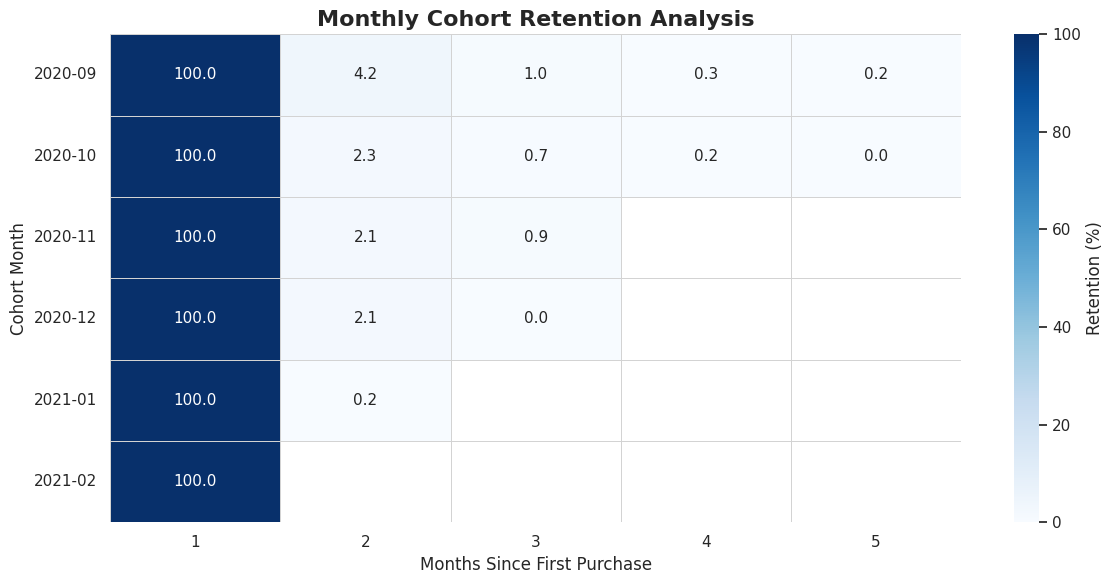

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.figure(figsize=(12, 6))

heatmap = sns.heatmap(
    retention_pct,
    mask=retention_pct.isna(),
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    linecolor='lightgray',
    cbar_kws={'label': 'Retention (%)'},
    annot_kws={"size": 11}
)

plt.title("Monthly Cohort Retention Analysis", fontsize=16, weight='bold')
plt.xlabel("Months Since First Purchase", fontsize=12)
plt.ylabel("Cohort Month", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Funnel per product

In [ ]:
df['event_type'].value_counts()

,count
event_type,
view,648113
cart,42789
purchase,29814


In [ ]:
funnel_product= (
    df.groupby(['product_id', 'event_type'])['user_id']
    .nunique()
    .unstack(fill_value=0)
    .reset_index()
)

funnel_product.head()


/tmp/ipython-input-902653052.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['product_id', 'event_type'])['user_id']


event_type,product_id,cart,purchase,view
0,1000108,0,0,26
1,1000111,2,0,37
2,1000112,0,0,15
3,1000113,0,0,10
4,1000116,0,0,14


In [ ]:
# Reorder kolom
funnel_product= funnel_product[
    ['product_id', 'view', 'cart', 'purchase']
]

funnel_product.sort_values(by='view', ascending=False).head()

event_type,product_id,view,cart,purchase
15341,1821813,4200,650,259
14205,1785245,2589,212,126
27478,3829355,2350,447,285
26355,3791351,2349,489,201
44050,809948,2111,200,105


In [ ]:
# Hindari division by zero
funnel_product['view_to_cart_rate'] = (
    funnel_product['cart'] / funnel_product['view']
).replace([float('inf')], 0).fillna(0)

funnel_product['cart_to_purchase_rate'] = (
    funnel_product['purchase'] / funnel_product['cart']
).replace([float('inf')], 0).fillna(0)

funnel_product['view_to_purchase_rate'] = (
    funnel_product['purchase'] / funnel_product['view']
).replace([float('inf')], 0).fillna(0)


In [ ]:
funnel_product['drop_view_to_cart'] = (
    funnel_product['view'] - funnel_product['cart']
)

funnel_product['drop_cart_to_purchase'] = (
    funnel_product['cart'] - funnel_product['purchase']
)

funnel_product['drop_view_to_cart_pct'] = (
    funnel_product['drop_view_to_cart'] / funnel_product['view'] * 100
).round(2)

funnel_product['drop_cart_to_purchase_pct'] = (
    funnel_product['drop_cart_to_purchase'] / funnel_product['cart'] * 100
).round(2)


In [ ]:
funnel_product_filtered = funnel_product[
    funnel_product['view'] >= 100
].sort_values(by='drop_view_to_cart_pct', ascending=False)

funnel_product_filtered.head(10)


event_type,product_id,view,cart,purchase,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,drop_view_to_cart,drop_cart_to_purchase,drop_view_to_cart_pct,drop_cart_to_purchase_pct
147,1006506,127,0,0,0.0,0.0,0.0,127,0,100.0,NaN
44191,811491,109,0,0,0.0,0.0,0.0,109,0,100.0,NaN
47440,876509,186,0,0,0.0,0.0,0.0,186,0,100.0,NaN
40023,665981,174,0,0,0.0,0.0,0.0,174,0,100.0,NaN
40781,695894,121,0,0,0.0,0.0,0.0,121,0,100.0,NaN
4416,1257933,155,0,0,0.0,0.0,0.0,155,0,100.0,NaN
43417,790653,324,0,0,0.0,0.0,0.0,324,0,100.0,NaN
3087,1144765,141,0,0,0.0,0.0,0.0,141,0,100.0,NaN
43700,799658,160,0,0,0.0,0.0,0.0,160,0,100.0,NaN
3257,1149272,185,0,0,0.0,0.0,0.0,185,0,100.0,NaN


In [ ]:
# Ambil average price per product
product_price = (
    df.groupby('product_id')['price']
      .mean()
      .reset_index()
)

# Merge ke funnel_product_filtered
funnel_product_filtered = funnel_product_filtered.merge(
    product_price,
    on='product_id',
    how='left'
)

In [ ]:
product_category = (
    df.groupby('product_id')['category_code']
      .first()
      .reset_index()
)

funnel_product_filtered = funnel_product_filtered.merge(
    product_category,
    on='product_id',
    how='left'
)

In [ ]:
# change datatype
df['event_type'] = df['event_type'].astype('object')

In [ ]:
view = df[df['event_type'] == 'view'].shape[0]
cart = df[df['event_type'] == 'cart'].shape[0]
purchase = df[df['event_type'] == 'purchase'].shape[0]

view_to_cart = cart / view * 100
cart_to_purchase = purchase / cart * 100
view_to_purchase = purchase / view * 100

view_to_cart, cart_to_purchase, view_to_purchase

(6.6020894504507694, 69.67678608988291, 4.60012374385331)

In [ ]:
# Top 5 product yang paling banyak dilihat
funnel_product_filtered.sort_values(by='view', ascending=False).head()

,product_id,view,cart,purchase,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,drop_view_to_cart,drop_cart_to_purchase,drop_view_to_cart_pct,drop_cart_to_purchase_pct,price,category_code
425,1821813,4200,650,259,0.154762,0.398462,0.061667,3550,391,84.52,60.15,397.48,computers.components.videocards
295,1785245,2589,212,126,0.081885,0.594340,0.048667,2377,86,91.81,40.57,43.11,stationery.cartrige
463,3829355,2350,447,285,0.190213,0.637584,0.121277,1903,162,80.98,36.24,32.22,electronics.telephone
481,3791351,2349,489,201,0.208174,0.411043,0.085568,1860,288,79.18,58.90,204.29,computers.components.cpu
332,809948,2111,200,105,0.094742,0.525000,0.049739,1911,95,90.53,47.50,64.48,computers.components.motherboard


In [ ]:
# Top 5 product yang paling banyak dimasukan keranjang
funnel_product_filtered.sort_values(by='cart', ascending=False).head()

,product_id,view,cart,purchase,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,drop_view_to_cart,drop_cart_to_purchase,drop_view_to_cart_pct,drop_cart_to_purchase_pct,price,category_code
425,1821813,4200,650,259,0.154762,0.398462,0.061667,3550,391,84.52,60.15,397.48,computers.components.videocards
565,4099645,1829,549,248,0.300164,0.451730,0.135593,1280,301,69.98,54.83,292.83,computers.components.videocards
481,3791351,2349,489,201,0.208174,0.411043,0.085568,1860,288,79.18,58.90,204.29,computers.components.cpu
463,3829355,2350,447,285,0.190213,0.637584,0.121277,1903,162,80.98,36.24,32.22,electronics.telephone
576,893196,872,284,134,0.325688,0.471831,0.153670,588,150,67.43,52.82,214.10,computers.components.videocards


In [ ]:
# Top 5 product yang paling banyak dimasukan keranjang
funnel_product_filtered.sort_values(by='purchase', ascending=False).head()

,product_id,view,cart,purchase,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,drop_view_to_cart,drop_cart_to_purchase,drop_view_to_cart_pct,drop_cart_to_purchase_pct,price,category_code
463,3829355,2350,447,285,0.190213,0.637584,0.121277,1903,162,80.98,36.24,32.22,electronics.telephone
425,1821813,4200,650,259,0.154762,0.398462,0.061667,3550,391,84.52,60.15,397.48,computers.components.videocards
565,4099645,1829,549,248,0.300164,0.451730,0.135593,1280,301,69.98,54.83,292.83,computers.components.videocards
481,3791351,2349,489,201,0.208174,0.411043,0.085568,1860,288,79.18,58.90,204.29,computers.components.cpu
555,3642540,763,220,169,0.288336,0.768182,0.221494,543,51,71.17,23.18,26.19,stationery.cartrige


In [ ]:
# Top 5 product drop customer view -> cart
funnel_product_filtered.sort_values(by='drop_view_to_cart_pct', ascending=False).head()

,product_id,view,cart,purchase,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,drop_view_to_cart,drop_cart_to_purchase,drop_view_to_cart_pct,drop_cart_to_purchase_pct,price,category_code
29,1529741,176,0,0,0.0,0.0,0.0,176,0,100.0,NaN,12.89,unknown
30,620535,100,0,0,0.0,0.0,0.0,100,0,100.0,NaN,406.43,computers.peripherals.joystick
31,641724,101,0,0,0.0,0.0,0.0,101,0,100.0,NaN,36.43,unknown
23,145379,320,0,0,0.0,0.0,0.0,320,0,100.0,NaN,57.27,computers.components.cpu
22,1455388,137,0,0,0.0,0.0,0.0,137,0,100.0,NaN,58.02,unknown


In [ ]:
# Top 5 product drop customer cart -> purchase
funnel_product_filtered.sort_values(by='drop_cart_to_purchase_pct', ascending=False).head()

,product_id,view,cart,purchase,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,drop_view_to_cart,drop_cart_to_purchase,drop_view_to_cart_pct,drop_cart_to_purchase_pct,price,category_code
102,83737,442,1,0,0.002262,0.0,0.0,441,1,99.77,100.0,140.02,auto.accessories.player
103,698803,368,1,0,0.002717,0.0,0.0,367,1,99.73,100.0,150.78,unknown
104,336049,252,1,0,0.003968,0.0,0.0,251,1,99.60,100.0,13.49,unknown
105,4100512,242,1,0,0.004132,0.0,0.0,241,1,99.59,100.0,168.22,unknown
134,370073,120,1,0,0.008333,0.0,0.0,119,1,99.17,100.0,185.44,computers.peripherals.printer


In [ ]:
funnel_product_filtered['view_to_purchase_rate_pct'] = \
    (funnel_product_filtered['view_to_purchase_rate'] * 100).round(2)

In [ ]:
funnel_product_filtered.sort_values(by='view_to_purchase_rate_pct', ascending=False).head()

,product_id,view,cart,purchase,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,drop_view_to_cart,drop_cart_to_purchase,drop_view_to_cart_pct,drop_cart_to_purchase_pct,price,category_code,view_to_purchase_rate_pct
584,8093,104,46,31,0.442308,0.673913,0.298077,58,15,55.77,32.61,23.17,stationery.cartrige,29.81
581,3829374,127,46,37,0.362205,0.804348,0.291339,81,9,63.78,19.57,21.43,electronics.telephone,29.13
557,885572,169,49,46,0.289941,0.938776,0.272189,120,3,71.01,6.12,21.21,stationery.cartrige,27.22
579,3828891,166,58,45,0.349398,0.775862,0.271084,108,13,65.06,22.41,51.33,electronics.telephone,27.11
583,1038724,105,40,26,0.380952,0.650000,0.247619,65,14,61.90,35.00,10.21,unknown,24.76


In [ ]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,year,month,day,hour,day_name
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,unknown,31.90,1.5159156255193882e+18,LJuJVLEjPT,2020-09-24,2020,9,24,11,Thursday
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1.5159156255193805e+18,tdicluNnRY,2020-09-24,2020,9,24,11,Thursday
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,unknown,unknown,9.81,1.5159156255132385e+18,4TMArHtXQy,2020-09-24,2020,9,24,11,Thursday
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1.5159156255190144e+18,aGFYrNgC08,2020-09-24,2020,9,24,11,Thursday
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,unknown,cameronsino,15.87,1.5159156255107433e+18,aa4mmk0kwQ,2020-09-24,2020,9,24,11,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721274,2021-02-01 13:09:47+00:00,view,3506612,2144415922872385653,electronics.tablet,arian,47.14,1.5159156255600735e+18,1tLdOwzjxO,2021-02-01,2021,2,1,13,Monday
721275,2021-02-01 13:09:52+00:00,cart,1821815,2144415922427789416,computers.components.videocards,gigabyte,446.51,1.515915625599429e+18,pYn40Zxfxu,2021-02-01,2021,2,1,13,Monday
721276,2021-02-01 13:09:54+00:00,view,408472,2144415925011480748,stationery.cartrige,unknown,14.08,1.5159156255987471e+18,XJjdH5NCcW,2021-02-01,2021,2,1,13,Monday
721277,2021-02-01 13:10:02+00:00,view,1255182,2144415942568837766,unknown,ion,205.89,1.51591562559807e+18,rMSjLgYQu0,2021-02-01,2021,2,1,13,Monday


pareto

In [ ]:
category_revenue = (
    df_purchase[df_purchase['category_code'] != 'unknown']
    .groupby('category_code')['price']
    .sum()
    .sort_values(ascending=False)
)

top21 = category_revenue.head(21)
top21_list = top21.index

df_purchase['category_grouped'] = df_purchase['category_code'].apply(
    lambda x: 'Top 21 Categories'
    if x in top21_list
    else ('unknown' if x == 'unknown' else x)
)

final_counts = (
    df_purchase
    .groupby('category_grouped')['price']
    .sum()
    .sort_values(ascending=False)
)


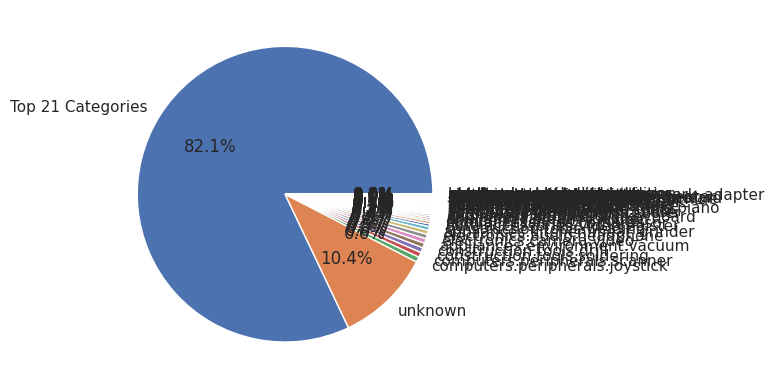

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
final_counts.plot.pie(autopct='%1.1f%%')
plt.ylabel('')
plt.show()

In [ ]:
df_purchase.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session', 'date',
       'year', 'month', 'day', 'hour', 'day_name', 'first_purchase_time',
       'customer_type', 'segment', 'total_orders', 'is_repeat',
       'category_grouped'],
      dtype='object')

In [ ]:
funnel_product_filtered.to_csv('funnel_product.csv', index=False)
from google.colab import files
files.download('funnel_product.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv('dftht.csv', index=False)
from google.colab import files
files.download('dftht.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#df_purchase.to_csv('purchase_data.csv', index=False)
#from google.colab import files
#files.download('purchase_data.csv')

In [ ]:
df_purchase

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,...,month,day,hour,day_name,first_purchase_time,customer_type,segment,total_orders,is_repeat,category_grouped
0,2020-09-24 12:04:10+00:00,purchase,1507291,2144415926806642904,computers.components.power_supply,supermicro,217.57,1.5159156255193905e+18,xn6SHCnZtk,2020-09-24,...,9,24,12,Thursday,2020-09-24 12:04:10+00:00,New,Churn Risk,1,0,Top 21 Categories
1,2020-09-24 12:15:06+00:00,purchase,822426,2144415922360680550,computers.peripherals.camera,logitech,123.35,1.5159156255135744e+18,2gngxS29Ts,2020-09-24,...,9,24,12,Thursday,2020-09-24 12:15:06+00:00,New,Loyal but At Risk,5,1,Top 21 Categories
2,2020-09-24 12:19:01+00:00,purchase,4060928,2144415927049912542,electronics.video.tv,unknown,89.22,1.515915625518131e+18,3yFCkx2KKW,2020-09-24,...,9,24,12,Thursday,2020-09-24 12:19:01+00:00,New,Loyal but At Risk,2,1,Top 21 Categories
3,2020-09-24 12:25:18+00:00,purchase,4060928,2144415927049912542,electronics.video.tv,unknown,89.22,1.515915625518131e+18,3yFCkx2KKW,2020-09-24,...,9,24,12,Thursday,2020-09-24 12:19:01+00:00,Returning,Loyal but At Risk,2,1,Top 21 Categories
4,2020-09-24 12:29:49+00:00,purchase,1283197,2144415973413749245,computers.peripherals.nas,zyxel,123.79,1.515915625519356e+18,3jFpdbozOd,2020-09-24,...,9,24,12,Thursday,2020-09-24 12:29:49+00:00,New,Loyal but At Risk,2,1,computers.peripherals.nas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29809,2021-02-01 12:38:51+00:00,purchase,3967707,2144415922427789416,computers.components.videocards,gigabyte,672.63,1.5159156255992172e+18,XArIldpbDi,2021-02-01,...,2,1,12,Monday,2021-02-01 12:38:51+00:00,New,High Value Customers,1,0,Top 21 Categories
29810,2021-02-01 12:43:43+00:00,purchase,1021721,2144415922528452715,electronics.telephone,unknown,28.73,1.51591562559942e+18,jD6tgS21kJ,2021-02-01,...,2,1,12,Monday,2021-02-01 12:43:43+00:00,New,Moderate Buyers,1,0,Top 21 Categories
29811,2021-02-01 12:52:49+00:00,purchase,3828952,2144415934608048556,computers.peripherals.printer,unknown,1.57,1.5159156255994212e+18,OYlVzrGegs,2021-02-01,...,2,1,12,Monday,2021-02-01 12:52:49+00:00,New,Moderate Buyers,1,0,Top 21 Categories
29812,2021-02-01 12:57:20+00:00,purchase,261142,2144415921253384266,unknown,unknown,38.83,1.5159156255994248e+18,If8P10VEuj,2021-02-01,...,2,1,12,Monday,2021-02-01 12:57:20+00:00,New,Moderate Buyers,1,0,unknown
